# Python - Exploratory Data Analysis 

Exploratory Data Analysis is the concept of having the first look at the data or doing preliminary analysis of the data at hand. Before diving into EDA, let's understand some important concepts related to data in general.

## Types of Data

Here are some exmples of data types that we may encounter in practice:

* Relational records

![](https://lh3.googleusercontent.com/proxy/Xp4d-tImtiHJGa8yXUHvOxh78vcKGj6QQyEEnw7MEvbk4pS0hEPS2YAsWZ2SCu2oRKppeTFu2otBZW_EyQGc3S4C9lsJ93ynSRvBKntfByD3zQ)

* Transactions

![](https://miro.medium.com/max/940/1*908489_PRdpPMctC6MT6OQ.png)

* Data Matrix (usual datasets)

* Word frequencies in documents

![](https://miro.medium.com/max/1608/1*tysdfR9Pq8UJm4rjfqzQcA.png)

* Graphs and networks

![](https://lh3.googleusercontent.com/proxy/pOwBfNKn0fMTY7oYl2D0ixVo24QiGD46UEq9CorRg16veUKtBq4zr48dP6ZBVVDMPmXm4d_owPKTRXJs_oUnrDvIm5TfXJD93BHeeyOozq45NZ_WEO_Eulxb5Xz8JzSmDF-m0pyGGewW)

* Temporal data (time series)

![](https://www.researchgate.net/profile/Paris_Perdikaris/publication/326799515/figure/fig4/AS:655380996702209@1533266414202/The-financial-time-series-data-used-to-calibrate-the-model-The-blue-curve-shows-the.png)

* Audio data

![](https://i.stack.imgur.com/fuK6Q.png)

* Video data (sequence of frames)

![](https://pbs.twimg.com/media/Bg9d8yCIgAAx5Gv.jpg)

* Spatial data (maps)

![](https://www.esri.com/arcgis-blog/wp-content/uploads/2018/02/05-fig-5-4-v2.png)

* Images


Data sets (datasets) are made up of **data objects** (e.g. entities, examples, data points etc.). These data objects are described by attributes also called as properties, features etc. 

This is the standard way of characterizing data attributes:

* Qualitative (categorical)
  - Nominal 
  - Ordinal
* Quantitiative (numeric)
  - Interval
  - Ratio

| | Attribute type      | Supported Operations |
| ---- | ----------- | ----------- |
| Categorical | Nominal      | $=$, $\neq$       |
| | Ordinal | $=$, $\neq$, $<$, $>$ | 
| Numeric | Interval   |   $=$, $\neq$, $<$, $>$, $+$, $-$    |
|| Ratio | $=$, $\neq$, $<$, $>$, $+$, $-$, $\cdot$, $/$ |

For example:

* Name of a person (Nominal) - Not meaningful to divide or subtract, or compare (unless the alphabetical order is important)

* Phone number (Nominal) - Not meaningful to divide, subtract, compare

* Salary (Ratio) - makes sense to do all sorts of numeric operations

* Date of birth (Interval) - doesn't make sense to divide dates

* Homework grade e.g in A-F scale (Ordinal)

* Temperature (Interval)

When looking at a new dataset, usually the first things we do is to

* determine the types of attributes (nominal / ordinal / numeric)

* have a look at each of the attributes separately (typically via visualization) 
  - to have an overall idea about the attribute
  - to notice any anomalies, outliers

We will demonstrate these ideas on some datasets. 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# the look at the data(via Notepad++) tells us
# that the data is tab(\t) seperated

data = pd.read_csv('Lab19_adult.csv',
                    sep='\t')

data.head()

,X,age,workclass,education,occupation,capital.gain,capital.loss,native.country,salaries,jobsatisfaction,male,female
0,0,39,State-gov,Bachelors,Adm-clerical,2174,0,United-States,43136.0,0,1.0,NaN
1,1,50,Self-emp-not-inc,Bachelors,Exec-managerial,0,0,UnitedStates,46209.0,7,1.0,NaN
2,2,38,privat,HS-grad,Handlers-cleaners,0,0,United-States,28937.0,6,1.0,NaN
3,3,53,privat,11th,Handlers-cleaners,0,0,United-States,33658.0,6,1.0,NaN
4,4,28,privat,Bachelors,Prof-specialty,0,0,Cuba,34372.0,12,NaN,1.0


## Data Understanding

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   X                32561 non-null  int64  
 1   age              32561 non-null  object 
 2   workclass        32561 non-null  object 
 3   education        32561 non-null  object 
 4   occupation       32561 non-null  object 
 5   capital.gain     32561 non-null  int64  
 6   capital.loss     32561 non-null  int64  
 7   native.country   32561 non-null  object 
 8   salaries         32561 non-null  float64
 9   jobsatisfaction  32561 non-null  object 
 10  male             21790 non-null  float64
 11  female           10771 non-null  float64
dtypes: float64(3), int64(3), object(6)
memory usage: 3.0+ MB


Here is an overall description of the dataset attributes:

$X$ - column showing the index of the row(person), the numbering starts from $0$ and there are $32561$ rows, so this dataframe contains info about $32561$ people 

$age$ - shows the age of a particular person 

$workclass$ - shows employment type(Government, Private sector, Self employed) 

$education$ - shows the degree of 
education(Bachelors, High School etc) 

$occupation$ - shows the type of the position of the person 

$capital.gain$ - shows earned money from investments(not connected to work) 

$capital.loss$ - shows the amount of lost money from investments(not connected to work) 

$native.country$ - the origin of the person 

$salaries$ - wage amount of the person 

$jobsatisfaction$ - number showing the level of satisfaction from work of a particular person 

$male$ - binary variable showing if a person is a male (==1) or not(NaN) 

$female$ - binary variable showing if a person is a female (==1) or not(NaN).  

Now let's visaulize each of the attributes and describe their types.

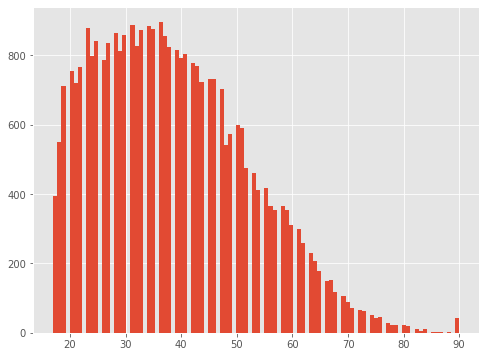

In [ ]:
# age column frequency histogram
# ‘coerce’ -> invalid parsing will be set as NaN
plt.style.use("ggplot") 
plt.rcParams['figure.figsize'] = (8, 6)
age = pd.to_numeric(data['age'], errors='coerce')
age[(0 < age) & (age < 100)].hist(bins=100);
# plt.yscale('log'); 

In [ ]:
input('What is the attribute type? ')

What is the attribute type? numeric (ratio)


'numeric (ratio)'

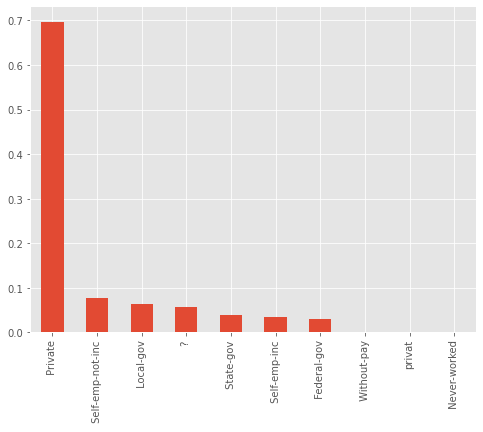

In [ ]:
# workclass (relative frequency histogram)
work_class = data['workclass'].value_counts()
work_class = work_class/sum(work_class)
work_class.plot(kind = 'bar');

In [ ]:
input('What is the attribute type? ')

What is the attribute type? nominal


'nominal'

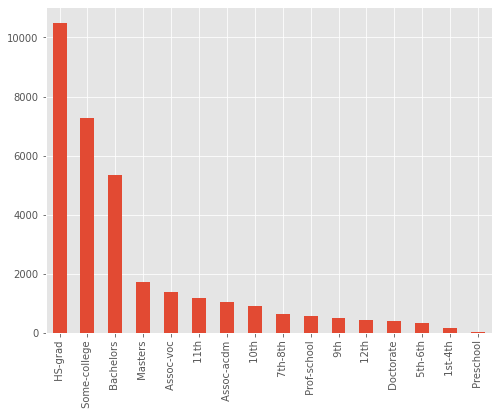

In [ ]:
# education (freq histogram)
data['education'].value_counts().plot(kind = 'bar');

In [ ]:
input('What is the attribute type? ')

What is the attribute type? ordinal


'ordinal'

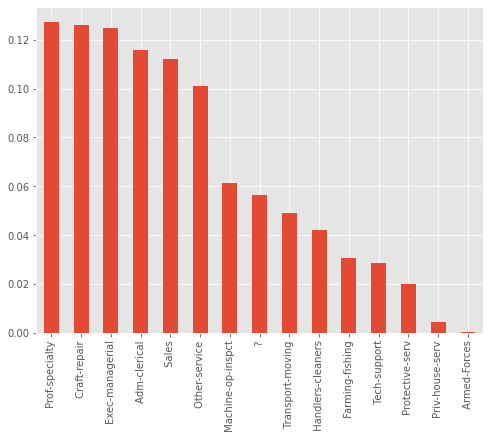

In [ ]:
# occupation (relative frequency histogram)
occup = data['occupation'].value_counts()
occup = occup/sum(occup)
occup.plot(kind = 'bar');

In [ ]:
input('What is the attribute type? ')

What is the attribute type? nominal


'nominal'

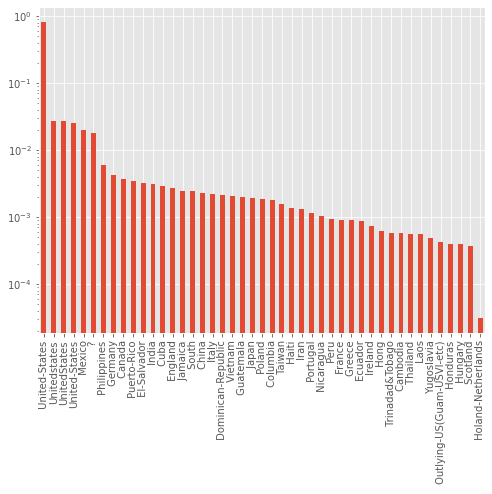

In [ ]:
# native country (relative frequency histogram)
native_country = data['native.country'].value_counts()
native_country = native_country/sum(native_country)
native_country.plot(kind = 'bar')
plt.yscale('log');

In [ ]:
input('What is the attribute type? ')

What is the attribute type? nominal


'nominal'

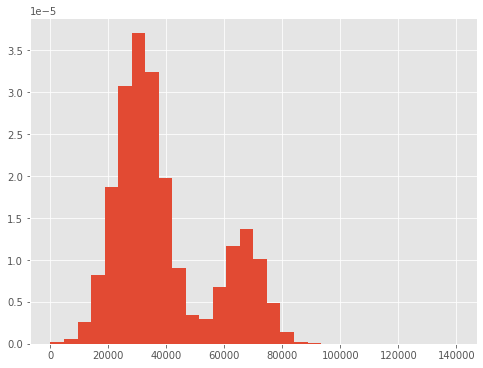

In [ ]:
# salaries (density histogram)
# by default: bins = auto
data['salaries'].hist(bins = 30, density = True); 

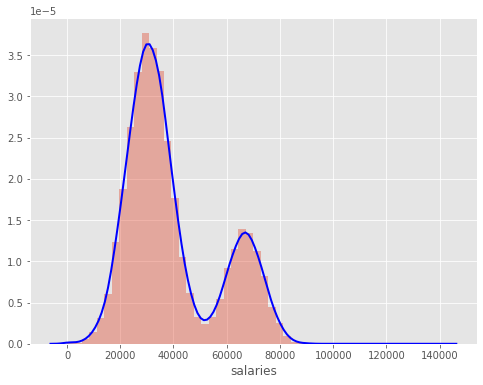

In [ ]:
# actual density plot with kernel density estimation
sns.distplot(data['salaries'],
             kde_kws={"color": "blue",
                      "linewidth": 2});

In [ ]:
input('What is the attribute type? ')

What is the attribute type? ratio


'ratio'

In [ ]:
gender = data['male'].fillna(0).map({1:'male', 0:'female'})

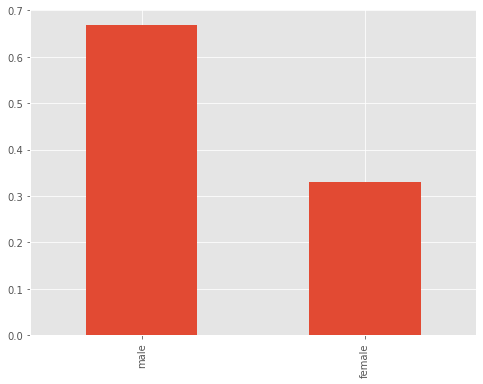

In [ ]:
# male vs female (relative freq hist)
gender = gender.value_counts()
gender /= sum(gender) 
gender.plot(kind='bar');

In [ ]:
input('What is the attribute type? ')

What is the attribute type? nominal


'nominal'

Now let's count the number of missing values in each attribute in the dataset and also report the percentage of missing values out of all rows ( original file uses '?' for missing values).

In [ ]:
missing_value = data.apply(lambda x: x == ' ?')
# percentage of missing values in each attribute
missing_value.sum() / len(missing_value) * 100

/usr/local/lib/python3.6/dist-packages/pandas/core/ops/array_ops.py:253: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  res_values = method(rvalues)


X                  0.000000
age                0.297902
workclass          5.638647
education          0.000000
occupation         5.660146
capital.gain       0.000000
capital.loss       0.000000
native.country     1.790486
salaries           0.000000
jobsatisfaction    0.000000
male               0.000000
female             0.000000
dtype: float64

In [ ]:
data.head()

## Data Preparation

Preparing the data for analysis is the most crucial phase in data analysis. In this exercise, the main goal is to clean up the dataset 'adult'. The dataset has been made unclean on purpose so that you can practice cleaning it up. 

Additionally, some values have been introduced which are non-sensical due to the meaning of the attribute.

First, let's make a deep copy of the original DataFrame. Later we will compare it to the cleaned/modified DataFrame.

In [ ]:
# Make a deep copy, including a copy of the data and the indices
original_data = data.copy() 

Sometimes values include leading and/or trailing spaces. Let's remove leading and trailing whitespace from strings. Count how many rows were changed in the dataset.

In [ ]:
for column in data.select_dtypes(include='object').columns:
    data[column] = data[column].astype(str).str.strip()        

In [ ]:
# Count differences
data_all = pd.concat([original_data, data]).drop_duplicates()
diff = data_all.shape[0] - data.shape[0]
print(f'Difference: {diff}')

Difference: 32561


In [ ]:
# Make a copy of the new DataFrame 
# where the leading and trailing whitespace are removed
data.age = pd.to_numeric(data.age, errors='coerce')
original_data = data.copy()

Now let's 

* replace all non-sensical values with np.nan from numpy package to denote missing values (Original file uses '?' for missing values). 

* fix the typos in the dataset. 

In [ ]:
# age
data.age[(data.age < 18) | (data.age > 100)] = np.nan

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [ ]:
# work class
data.workclass = data.workclass.replace('privat', 'Private') 

In [ ]:
data['native.country'] = data['native.country'].replace('Unitedstates',
                                                        'United-States')

data['native.country'] = data['native.country'].replace('UnitedStates',
                                                        'United-States')  

data['native.country'] = data['native.country'].replace('Holand-Netherlands',
                                                        'Netherlands')  

In [ ]:
# Capital Gain
data.loc[pd.to_numeric(data['capital.gain'],
                       errors='coerce') < 0,'capital.gain'] = np.nan

In [ ]:
# Capital Loss
data.loc[data['capital.loss'] < 0, 'capital.loss'] = np.nan

In [ ]:
# Education
data.education = data.education.replace('12th','HS-grad')

In [ ]:
# jobsatisfaction
data.jobsatisfaction[pd.to_numeric(data['jobsatisfaction'],
                       errors='coerce').isnull()] = np.nan

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [ ]:
# let's also change '?' to np.nan
data[data == '?'] = np.nan

/usr/local/lib/python3.6/dist-packages/pandas/core/ops/array_ops.py:253: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  res_values = method(rvalues)


In [ ]:
# Count differences
data_all = pd.concat([original_data, data]).drop_duplicates()
diff = data_all.shape[0] - data.shape[0]
print(f'Difference: {diff}')

Difference: 4729


There may ba some other suspicious values, but we can't be sure whether there has been an error or not.

## Preliminary analysis

Useful information about the data can be acquired through visualization even before modeling.

Let's convert education column to type category and put education in the ascending order based on educational level.

In [ ]:
from pandas.api.types import CategoricalDtype

ordered_education = ['Preschool', '1st-4th', '5th-6th',
                     '7th-8th', '9th', '10th','11th',
                     'HS-grad', 'Prof-school', 'Assoc-acdm',
                     'Assoc-voc', 'Some-college', 'Bachelors',
                     'Masters', 'Doctorate']

data.education = data.education.astype(
    CategoricalDtype(ordered = True,
                     categories = ordered_education))

In [ ]:
data.education

0         Bachelors
1         Bachelors
2           HS-grad
3              11th
4         Bachelors
            ...    
32556    Assoc-acdm
32557       HS-grad
32558       HS-grad
32559       HS-grad
32560       HS-grad
Name: education, Length: 32561, dtype: category
Categories (15, object): [Preschool < 1st-4th < 5th-6th < 7th-8th ... Some-college < Bachelors < Masters <
                          Doctorate]

We can transform the original dataset into a different representation to analyse the relationship between people's occupation and their education level.

In [ ]:
crossdf = pd.crosstab(data.occupation, data.education,
                      values=data.salaries, aggfunc=np.mean)
print(crossdf)

education             Preschool       1st-4th  ...       Masters     Doctorate
occupation                                     ...                            
Adm-clerical       31927.500000           NaN  ...  42550.852941  43041.600000
Armed-Forces                NaN           NaN  ...  67993.000000           NaN
Craft-repair       33937.500000  32884.086957  ...  46957.590909  54458.500000
Exec-managerial             NaN  50014.500000  ...  57455.882236  63967.981818
Farming-fishing    32559.333333  31450.000000  ...  40793.100000  70039.000000
Handlers-cleaners  30799.000000  31633.062500  ...  29983.000000           NaN
Machine-op-inspct  32628.818182  32227.956522  ...  31144.500000  70502.000000
Other-service      32498.466667  29770.650000  ...  32017.684211  71626.000000
Priv-house-serv    26577.000000  25066.363636  ...  28568.000000           NaN
Prof-specialty     34861.000000  23128.500000  ...  48030.883886  56764.623053
Protective-serv             NaN  41685.000000  ...  

We can visualize the above matrix in terms of a heatmap.

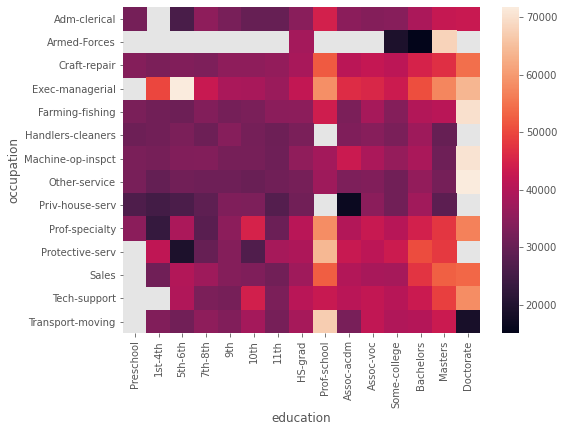

In [ ]:
sns.heatmap(crossdf);

Let's visualize the relationship between `age` and `salary` using a simple scatter plot.

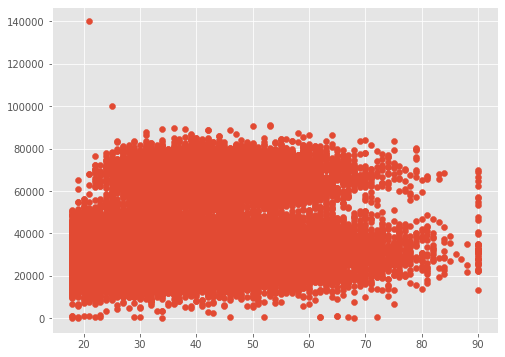

In [ ]:
data.salaries = pd.to_numeric(data.salaries)
plt.scatter(x=data['age'], y=data['salaries']);

Now let's discretize the `age` variable and have a look at the boxplot of `salary`s w.r.t each age group.

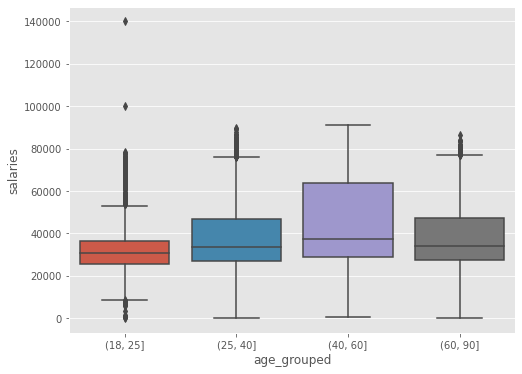

In [ ]:
data['age_grouped'] = pd.cut(data['age'], [18, 25, 40, 60, 90])
sns.boxplot(data=data, x='age_grouped', y='salaries');

We can also look at the **violinplot** in case we are interested in the estimated sensity function of the salaries per age groups.

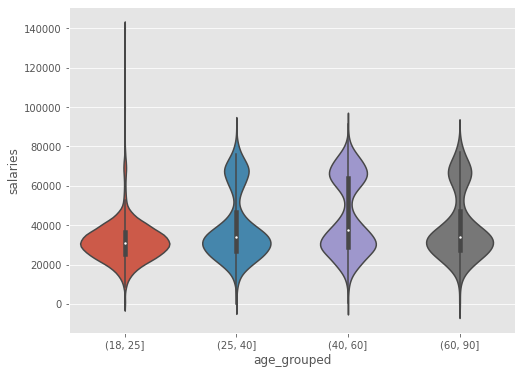

In [ ]:
sns.violinplot(data=data, x='age_grouped', y='salaries');

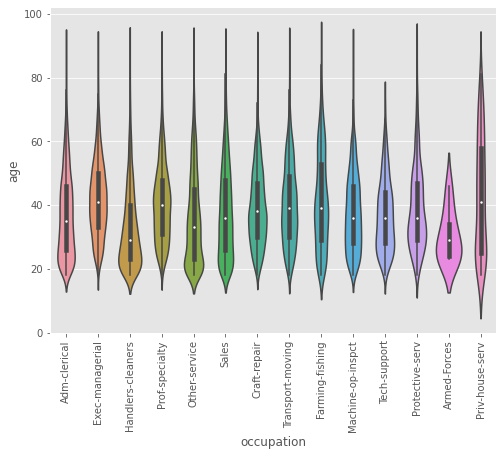

In [ ]:
sns.violinplot(data=data, x='occupation', y='age');
plt.xticks(rotation='vertical');

Remember that we can also visualize more than two attributes.

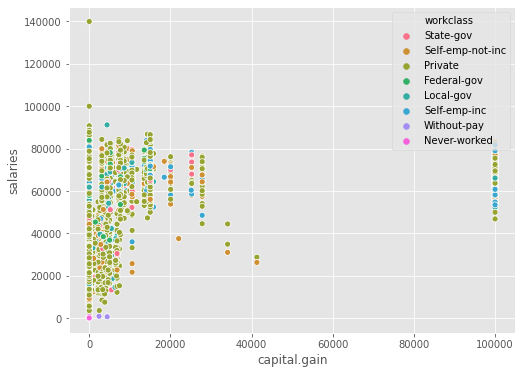

In [ ]:
sns.scatterplot(data=data,
                x='capital.gain',
                y='salaries',
                hue='workclass')
plt.legend(loc='upper right');

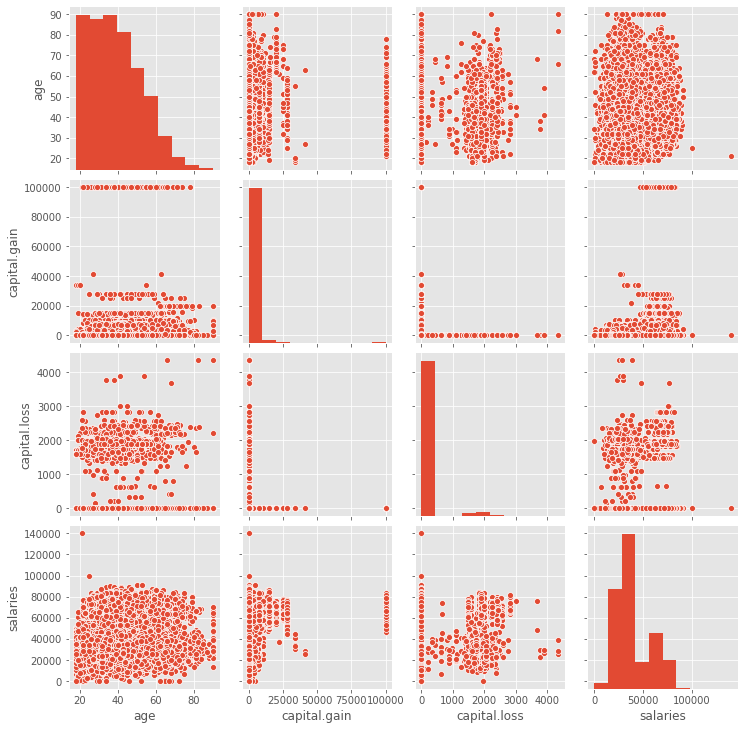

In [ ]:
sns.pairplot(data[['age', 'capital.gain', 'capital.loss', 'salaries']]);

# Visualisations about the dataset 'instacart'

The Instacart dataset is an online grocery shopping dataset. Note that this is just a small fraction of the full dataset. Read the [blog](https://tech.instacart.com/3-million-instacart-orders-open-sourced-d40d29ead6f2) entry announcing that the 'instacart' dataset is being made public.

In [ ]:
instadata = pd.read_csv('Lab19_instacart_100k.csv',
                        sep=',')

In [ ]:
instadata.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,2539329,1,prior,1,2,8,NaN,196.0,1.0,0.0,Soda,77.0,7.0,soft drinks,beverages
1,2539329,1,prior,1,2,8,NaN,14084.0,2.0,0.0,Organic Unsweetened Vanilla Almond Milk,91.0,16.0,soy lactosefree,dairy eggs
2,2539329,1,prior,1,2,8,NaN,12427.0,3.0,0.0,Original Beef Jerky,23.0,19.0,popcorn jerky,snacks
3,2539329,1,prior,1,2,8,NaN,26088.0,4.0,0.0,Aged White Cheddar Popcorn,23.0,19.0,popcorn jerky,snacks
4,2539329,1,prior,1,2,8,NaN,26405.0,5.0,0.0,XL Pick-A-Size Paper Towel Rolls,54.0,17.0,paper goods,household


In [ ]:
instadata.shape

(100000, 15)

Let's create a figure consisting of 7 histograms for each day of the week.
Each histogram has 24 bars, one for each hour of the day. The height of a bar corresponds to the number of product-purchases (it means number of rows) in the data that are performed in that hour of the corresponding day-of-the-week.



In [ ]:
instacross = pd.crosstab(instadata.order_dow,
                         instadata.order_hour_of_day,
                         values=instadata.product_id, aggfunc=len)

In [ ]:
instacross

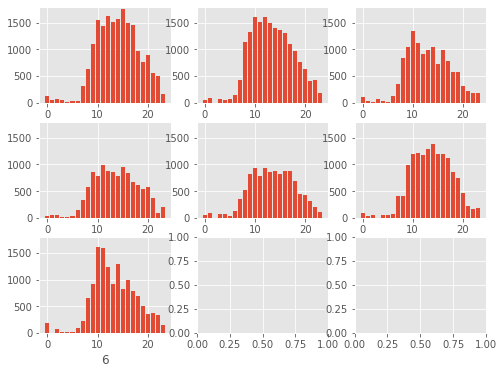

In [ ]:
fig, ax = plt.subplots(3, 3)

ax = ax.ravel()
for i in range(7):    
    ax[i].bar(np.arange(24), instacross.iloc[i,:])
    ax[i].set_xlabel(i)
    ax[i].set_ylim([0, 1800])

Notice that:
 
1. During the 6th day there are less sales(almost no sales) in the morning(0-5) and the most sales are done during the daytime(10,11).

2. During the 4th day the sales are almost constant during the daytime.

3. The sales tend to decrease from 18.

# Warm-up Exercise

Read the blog mentioned above and study the dataset to identify the type of each attribute (nominal/ordinal/numeric). Create another plot of this dataset that you think conveys interesting information. List 3 interesting facts that you can read out from that plot.


In [ ]:
## your code here

If you want to gain more experience in such kind of analysis, download [this](https://www.kaggle.com/zusmani/pakistandroneattacks) dataset and perform similar EDA operations on it.

You can also have a look at [this](https://www.kaggle.com/dejavu23/titanic-eda-to-ml-beginner) EDA example, which is performed on Titanic dataset. 
